In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor

import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully")

All libraries loaded successfully


In [40]:
# Load the dataset — update path if needed
df = pd.read_csv(r'C:\Users\DNYANESHWARI DEORE\Downloads\Course\2nd Year\MME\4TH SEM\PEM\ML PROJECT\HEAP LEACHING\comsol_results_fixed.csv')

print("Shape:", df.shape)
print("\nFirst 3 rows:")
df.head(3)

Shape: (200, 13)

First 3 rows:


,por,C0,u0,k_r,D_eff,X_1d,X_3d,X_7d,X_14d,X_21d,X_30d,X_45d,X_60d
0,0.40403,0.75953,0.000067,5.758000e-07,4.640000e-10,0.003780,0.011542,0.026990,0.05380,0.080376,0.114200,0.169765,0.224061
1,0.34753,0.83008,0.000067,8.756200e-07,4.130000e-10,0.004504,0.013709,0.032060,0.06404,0.095856,0.136549,0.203632,0.269564
2,0.29704,0.10483,0.000073,5.355800e-07,6.250000e-10,0.000541,0.001653,0.003876,0.00776,0.011640,0.016620,0.024900,0.033154


In [41]:
print("=== BASIC STATISTICS ===")
print(df.describe().round(4))

=== BASIC STATISTICS ===
            por        C0        u0    k_r  D_eff      X_1d      X_3d  \
count  200.0000  200.0000  200.0000  200.0  200.0  200.0000  200.0000   
mean     0.3750    0.5499    0.0001    0.0    0.0    0.0019    0.0058   
std      0.0724    0.2603    0.0000    0.0    0.0    0.0014    0.0044   
min      0.2503    0.1044    0.0000    0.0    0.0    0.0000    0.0001   
25%      0.3125    0.3270    0.0000    0.0    0.0    0.0008    0.0025   
50%      0.3753    0.5494    0.0001    0.0    0.0    0.0014    0.0043   
75%      0.4369    0.7750    0.0001    0.0    0.0    0.0028    0.0086   
max      0.4997    0.9966    0.0001    0.0    0.0    0.0067    0.0203   

           X_7d     X_14d     X_21d     X_30d     X_45d     X_60d  
count  200.0000  200.0000  200.0000  200.0000  200.0000  200.0000  
mean     0.0135    0.0269    0.0403    0.0573    0.0854    0.1130  
std      0.0101    0.0202    0.0301    0.0427    0.0632    0.0831  
min      0.0003    0.0005    0.0008    0.0011

In [42]:
print("Missing values:", df.isnull().sum().sum())

print("Negative X_yield values:",
      (df[['X_1d','X_3d','X_7d','X_14d',
           'X_21d','X_30d','X_45d','X_60d']] < 0).sum().sum())

print("X_60d > 1 (impossible):", (df['X_60d'] > 1).sum())

print("\nX_60d range:", round(df['X_60d'].min(), 4), "to", round(df['X_60d'].max(), 4))

print("\nAll checks passed ✅" if df.isnull().sum().sum() == 0 else "⚠️ Issues found")

Missing values: 0
Negative X_yield values: 0
X_60d > 1 (impossible): 0

X_60d range: 0.0023 to 0.373

All checks passed ✅


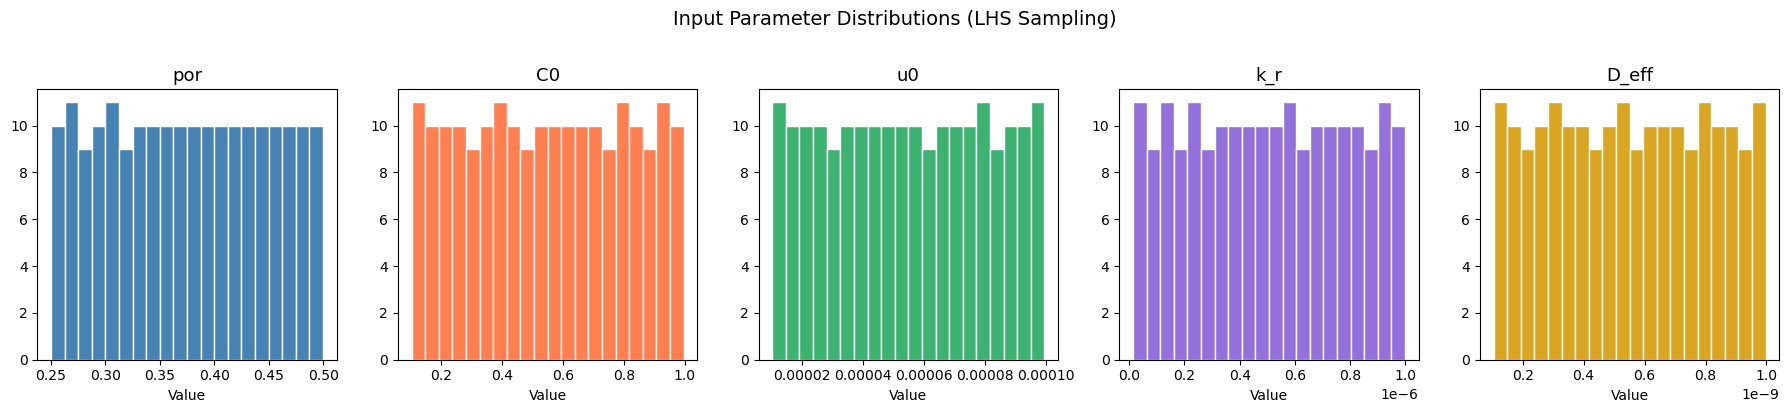

Plot saved


In [43]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
params = ['por', 'C0', 'u0', 'k_r', 'D_eff']
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple', 'goldenrod']

for ax, param, color in zip(axes, params, colors):
    ax.hist(df[param], bins=20, color=color, edgecolor='white')
    ax.set_title(param, fontsize=13)
    ax.set_xlabel('Value')

plt.suptitle('Input Parameter Distributions (LHS Sampling)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('input_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

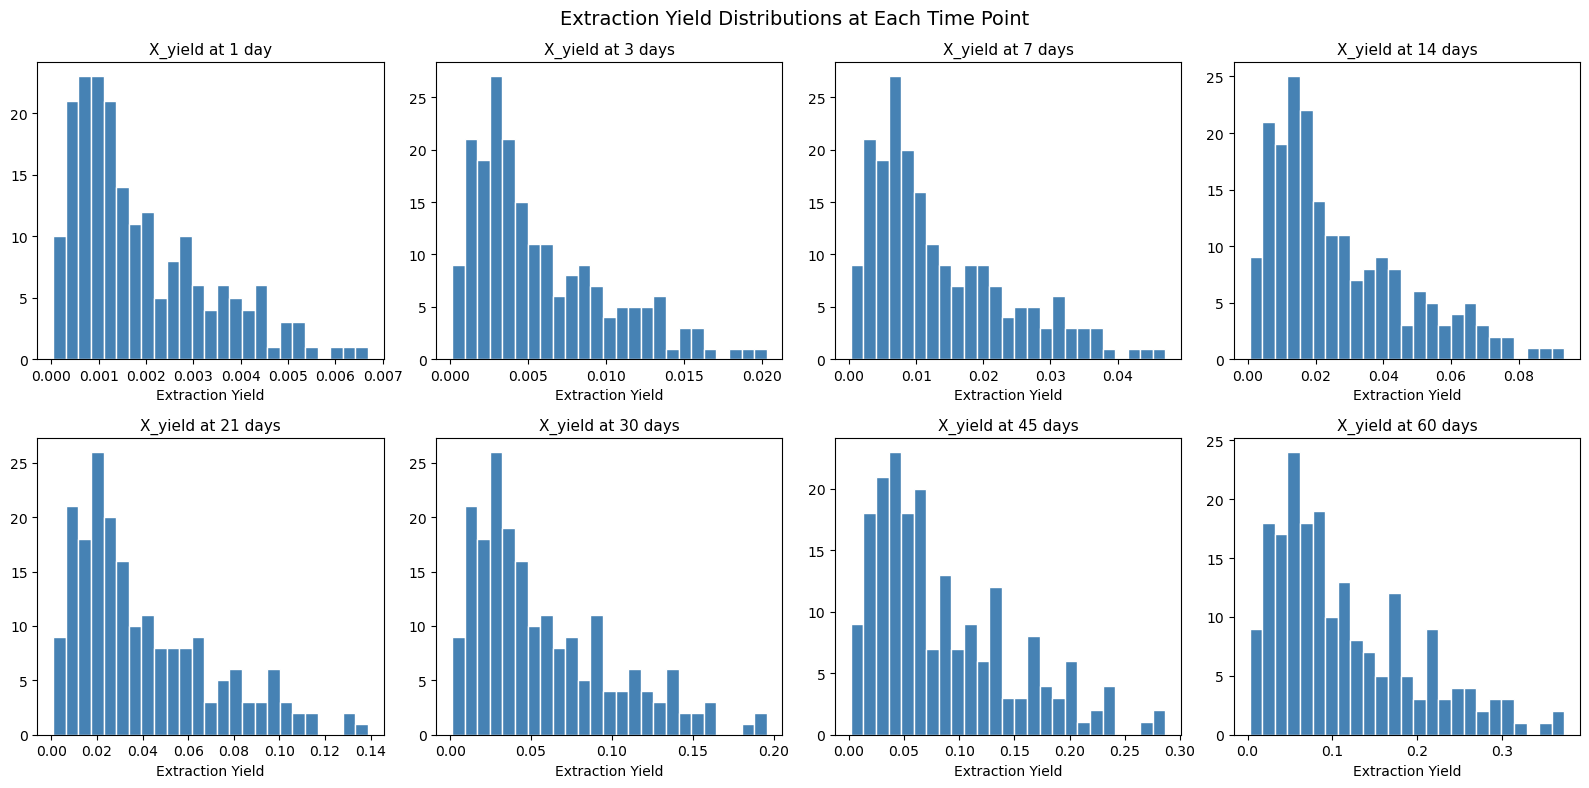

In [44]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
outputs = ['X_1d','X_3d','X_7d','X_14d','X_21d','X_30d','X_45d','X_60d']
labels  = ['1 day','3 days','7 days','14 days','21 days','30 days','45 days','60 days']

for ax, col, label in zip(axes, outputs, labels):
    ax.hist(df[col], bins=25, color='steelblue', edgecolor='white')
    ax.set_title(f'X_yield at {label}', fontsize=11)
    ax.set_xlabel('Extraction Yield')

plt.suptitle('Extraction Yield Distributions at Each Time Point', fontsize=14)
plt.tight_layout()
plt.savefig('output_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

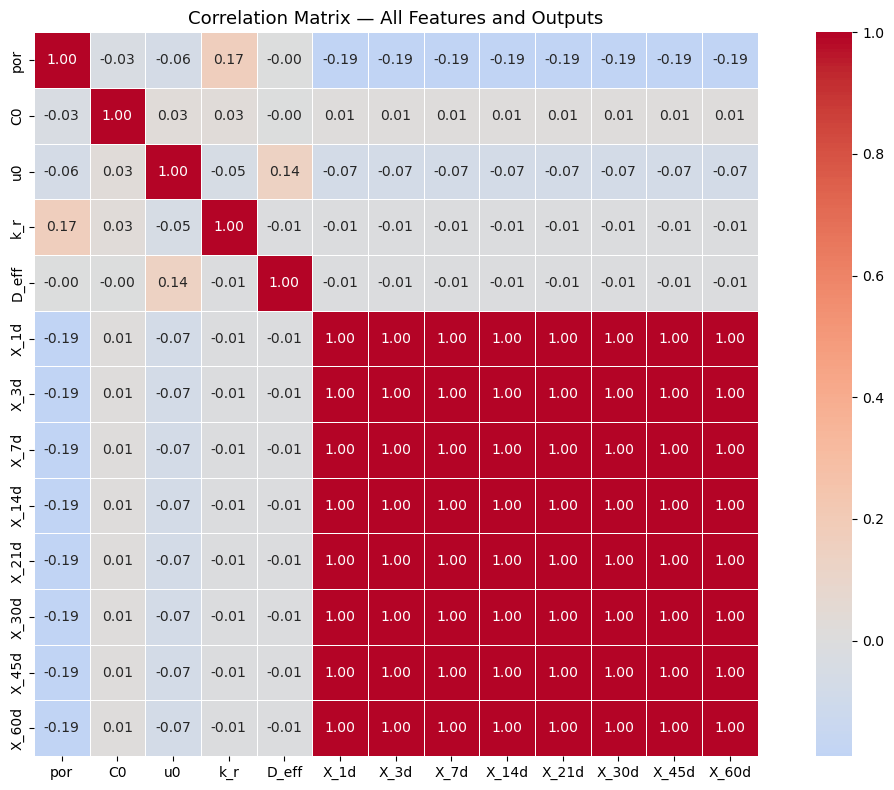

In [8]:
plt.figure(figsize=(12, 8))
corr = df.corr().round(2)
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix — All Features and Outputs', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# Define inputs and outputs
X = df[['por', 'C0', 'u0', 'k_r', 'D_eff']].values
y = df[['X_1d','X_3d','X_7d','X_14d','X_21d','X_30d','X_45d','X_60d']].values

# Split: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Training set:   {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set:       {X_test.shape[0]} samples")

Training set:   140 samples
Validation set: 30 samples
Test set:       30 samples


In [32]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print("Scaling done — mean ~0, std ~1 for all features")
print("Train mean:", X_train_sc.mean(axis=0).round(3))
print("Train std: ", X_train_sc.std(axis=0).round(3))

Scaling done — mean ~0, std ~1 for all features
Train mean: [-0. -0.  0.  0. -0.]
Train std:  [1. 1. 1. 1. 1.]


In [33]:
# Model 1: Linear Regression (baseline)
lr = MultiOutputRegressor(LinearRegression())
lr.fit(X_train_sc, y_train)

# Model 2: Random Forest
rf = RandomForestRegressor(n_estimators=200, 
                            max_depth=15,
                            min_samples_split=3,
                            random_state=42,
                            n_jobs=-1)
rf.fit(X_train_sc, y_train)

# Model 3: Gradient Boosting
gb = MultiOutputRegressor(
        GradientBoostingRegressor(n_estimators=200,
                                  max_depth=5,
                                  learning_rate=0.05,
                                  random_state=42))
gb.fit(X_train_sc, y_train)

print("All three models trained ✅")

All three models trained ✅


In [45]:
models = {'Linear Regression': lr, 
          'Random Forest': rf, 
          'Gradient Boosting': gb}

print(f"{'Model':<25} {'R² (val)':<12} {'RMSE (val)':<12}")
print("-" * 50)

results = {}
for name, model in models.items():
    y_pred = model.predict(X_val_sc)
    r2   = r2_score(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    results[name] = {'r2': r2, 'rmse': rmse, 'model': model}
    print(f"{name:<25} {r2:<12.4f} {rmse:<12.6f}")

Model                     R² (val)     RMSE (val)  
--------------------------------------------------
Linear Regression         0.8403       0.017701    
Random Forest             0.9620       0.008838    
Gradient Boosting         0.9597       0.009052    


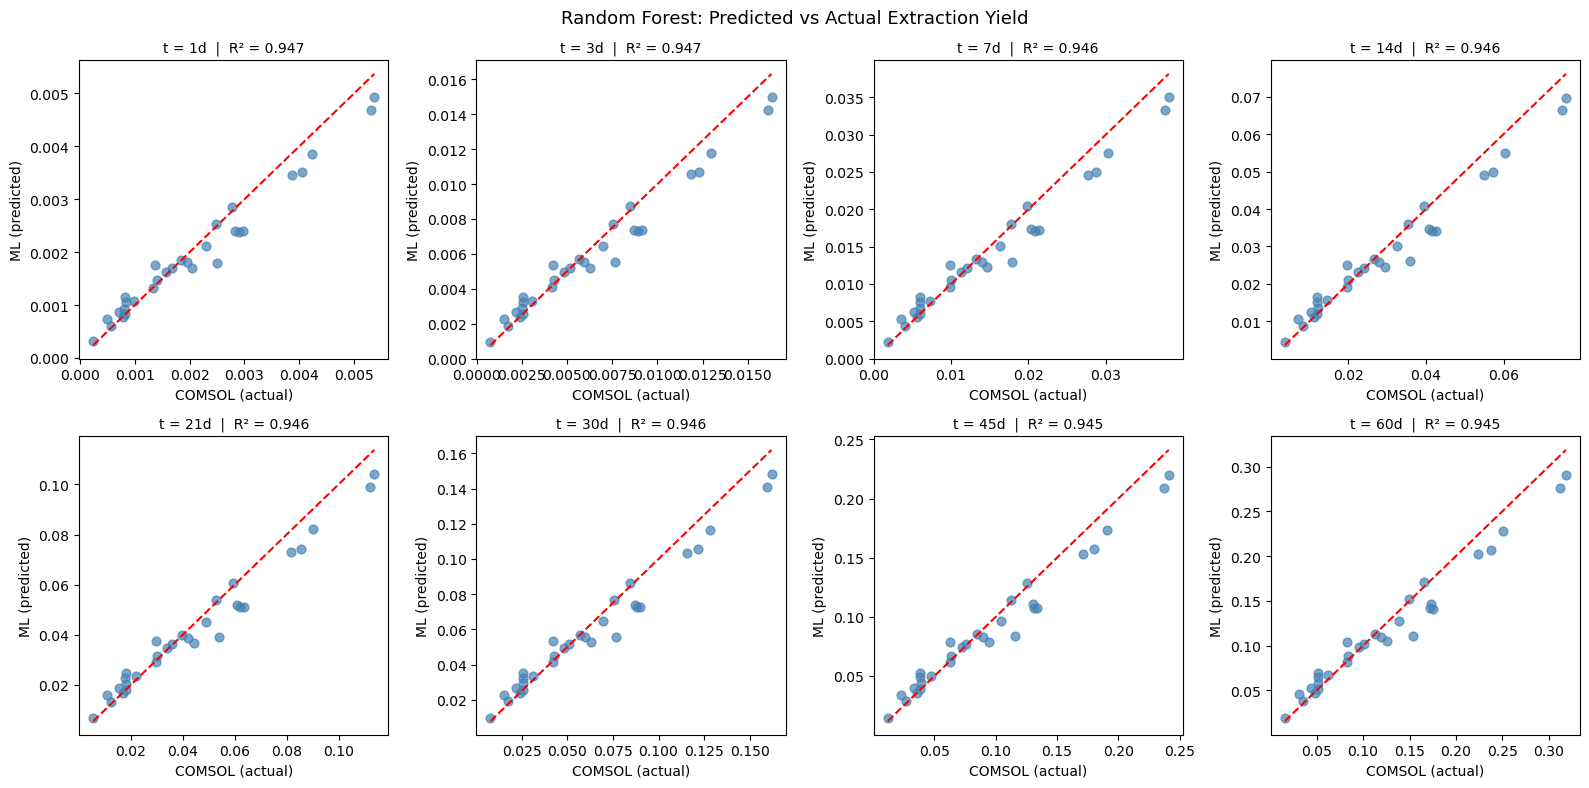

In [48]:
# Use Random Forest (likely best)
best_model = rf
y_pred_test = best_model.predict(X_test_sc)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
outputs = ['X_1d','X_3d','X_7d','X_14d','X_21d','X_30d','X_45d','X_60d']
labels  = ['1d','3d','7d','14d','21d','30d','45d','60d']

for i, (ax, label) in enumerate(zip(axes, labels)):
    ax.scatter(y_test[:, i], y_pred_test[:, i], 
               alpha=0.7, color='steelblue', s=40)
    lims = [min(y_test[:, i].min(), y_pred_test[:, i].min()),
            max(y_test[:, i].max(), y_pred_test[:, i].max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
    r2 = r2_score(y_test[:, i], y_pred_test[:, i])
    ax.set_title(f't = {label}  |  R² = {r2:.3f}', fontsize=10)
    ax.set_xlabel('COMSOL (actual)')
    ax.set_ylabel('ML (predicted)')

plt.suptitle('Random Forest: Predicted vs Actual Extraction Yield', fontsize=13)
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

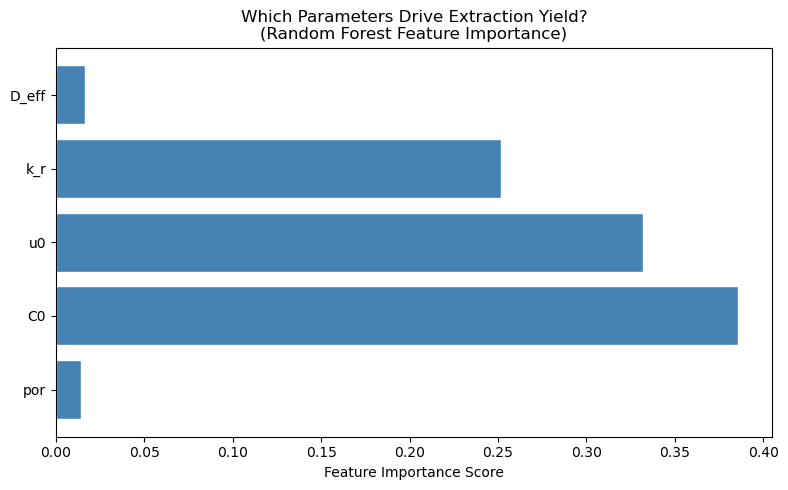


Feature importances:
  C0      : 0.3857
  u0      : 0.3320
  k_r     : 0.2518
  D_eff   : 0.0166
  por     : 0.0139


In [49]:
# Random Forest gives feature importance directly
importances = rf.feature_importances_
features = ['por', 'C0', 'u0', 'k_r', 'D_eff']

plt.figure(figsize=(8, 5))
bars = plt.barh(features, importances, color='steelblue', edgecolor='white')
plt.xlabel('Feature Importance Score')
plt.title('Which Parameters Drive Extraction Yield?\n(Random Forest Feature Importance)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFeature importances:")
for f, imp in sorted(zip(features, importances), key=lambda x: -x[1]):
    print(f"  {f:<8}: {imp:.4f}")

In [ ]:
# ADDING NEURAL NETWORK

In [59]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [65]:
from sklearn.preprocessing import StandardScaler

# Scale outputs too — ANN needs this unlike tree models
scaler_y = StandardScaler()
y_train_sc = scaler_y.fit_transform(y_train)
y_val_sc_out = scaler_y.transform(y_val)
y_test_sc_out = scaler_y.transform(y_test)

print("Output scaling done")
print("y_train mean:", y_train_sc.mean(axis=0).round(3))

Output scaling done
y_train mean: [-0.  0. -0.  0.  0. -0. -0. -0.]


In [70]:
# Rebuild model
model_ann = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(5,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(8)
])

model_ann.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse', metrics=['mae'])

es = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

history = model_ann.fit(
    X_train_sc, y_train_sc,          # scaled outputs
    validation_data=(X_val_sc, y_val_sc_out),
    epochs=500,
    batch_size=16,
    callbacks=[es],
    verbose=0
)
print(f"Training stopped at epoch: {len(history.history['loss'])}")

Training stopped at epoch: 82


In [72]:
# Predict and inverse transform back to original scale
y_pred_ann_sc = model_ann.predict(X_val_sc)
y_pred_ann = scaler_y.inverse_transform(y_pred_ann_sc)

r2_ann   = r2_score(y_val, y_pred_ann)
rmse_ann = np.sqrt(mean_squared_error(y_val, y_pred_ann))

print(f"\n=== FINAL MODEL COMPARISON ===")
print(f"{'Model':<25} {'R²':<10} {'RMSE':<10}")
print("-" * 45)
print(f"{'Linear Regression':<25} {0.8403:<10.4f} {0.017701:<10.6f}")
print(f"{'Random Forest':<25} {0.9620:<10.4f} {0.008838:<10.6f}")
print(f"{'Gradient Boosting':<25} {0.9597:<10.4f} {0.009052:<10.6f}")
print(f"{'Neural Network (ANN)':<25} {r2_ann:<10.4f} {rmse_ann:<10.6f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

=== FINAL MODEL COMPARISON ===
Model                     R²         RMSE      
---------------------------------------------
Linear Regression         0.8403     0.017701  
Random Forest             0.9620     0.008838  
Gradient Boosting         0.9597     0.009052  
Neural Network (ANN)      0.9902     0.004769  


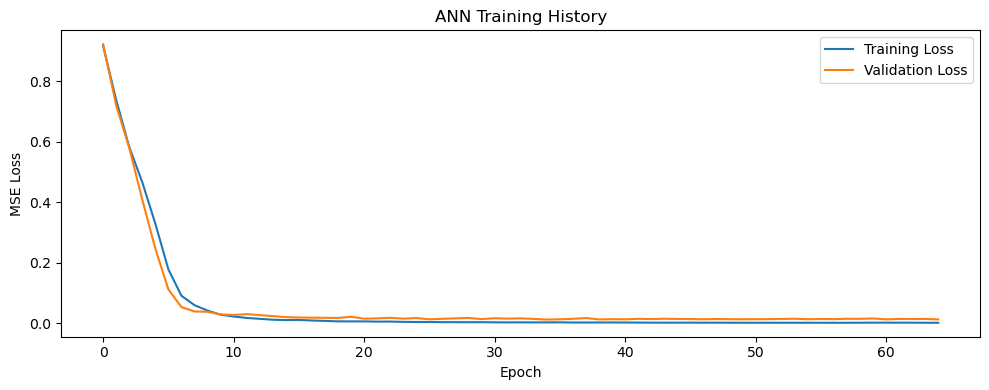

In [73]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('ANN Training History')
plt.legend()
plt.tight_layout()
plt.savefig('ann_training_history.png', dpi=150)
plt.show()

In [77]:
import joblib

joblib.dump(rf, 'random_forest_model.pkl')
joblib.dump(gb, 'gradient_boosting_model.pkl')
joblib.dump(scaler, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')
model_ann.save('ann_model.keras')

print("All models saved ✅")

All models saved ✅


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


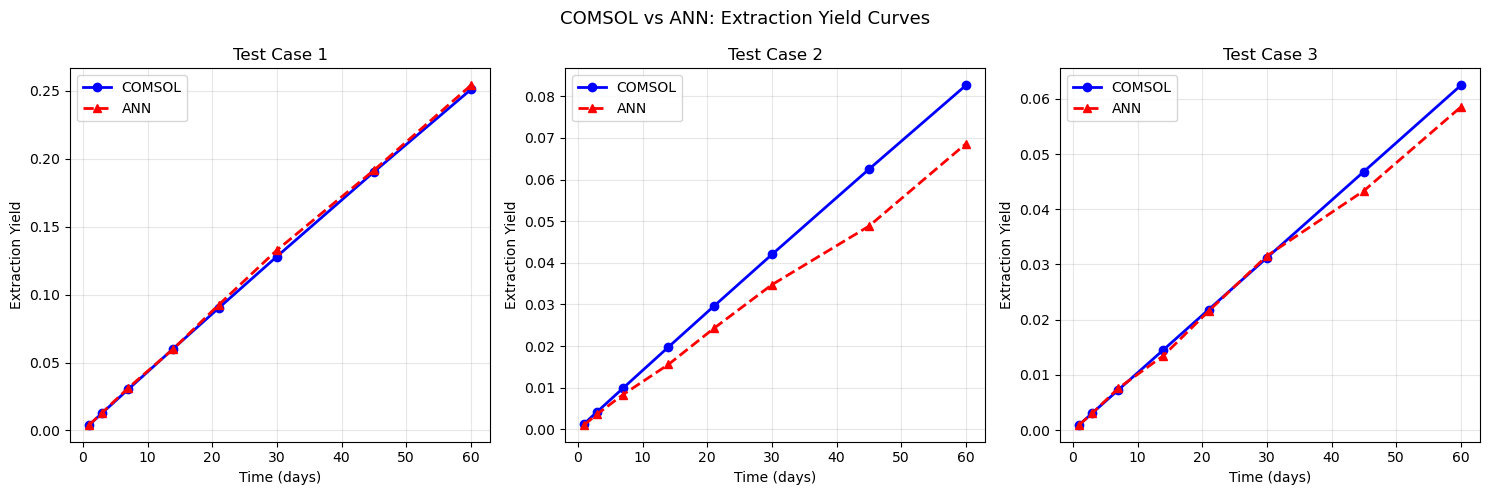

In [75]:
# Pick 3 test cases and compare COMSOL vs ANN prediction
time_days = [1, 3, 7, 14, 21, 30, 45, 60]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, ax in enumerate(axes):
    # COMSOL actual
    actual = y_test[idx]
    
    # ANN predicted
    pred_sc = model_ann.predict(X_test_sc[idx:idx+1])
    pred = scaler_y.inverse_transform(pred_sc)[0]
    
    ax.plot(time_days, actual, 'bo-', label='COMSOL', linewidth=2)
    ax.plot(time_days, pred,   'r^--', label='ANN', linewidth=2)
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Extraction Yield')
    ax.set_title(f'Test Case {idx+1}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('COMSOL vs ANN: Extraction Yield Curves', fontsize=13)
plt.tight_layout()
plt.savefig('extraction_curve_comparison.png', dpi=150)
plt.show()

In [76]:
print("=" * 50)
print("PROJECT SUMMARY")
print("=" * 50)
print(f"Dataset: 200 simulations × 13 features")
print(f"Train/Val/Test: 140 / 30 / 30")
print(f"\nBest Model: Neural Network (ANN)")
print(f"R² Score:   0.9902")
print(f"RMSE:       0.004769")
print(f"\nTop Feature: C0 (inlet acid concentration)")
print(f"2nd Feature: u0 (Darcy velocity)")
print(f"\nAll models and scalers saved ✅")
print("=" * 50)

PROJECT SUMMARY
Dataset: 200 simulations × 13 features
Train/Val/Test: 140 / 30 / 30

Best Model: Neural Network (ANN)
R² Score:   0.9902
RMSE:       0.004769

Top Feature: C0 (inlet acid concentration)
2nd Feature: u0 (Darcy velocity)

All models and scalers saved ✅


In [78]:
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

X_all = np.vstack([X_train_sc, X_val_sc])
y_all = np.vstack([y_train, y_val])

cv_rf = cross_val_score(rf, X_all, y_all, cv=kf, scoring='r2')
cv_gb = cross_val_score(gb, X_all, y_all, cv=kf, scoring='r2')
cv_lr = cross_val_score(lr, X_all, y_all, cv=kf, scoring='r2')

print("=== 5-FOLD CROSS VALIDATION ===")
print(f"Linear Regression: {cv_lr.mean():.4f} ± {cv_lr.std():.4f}")
print(f"Random Forest:     {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")
print(f"Gradient Boosting: {cv_gb.mean():.4f} ± {cv_gb.std():.4f}")

=== 5-FOLD CROSS VALIDATION ===
Linear Regression: 0.7457 ± 0.0995
Random Forest:     0.9278 ± 0.0147
Gradient Boosting: 0.9498 ± 0.0085


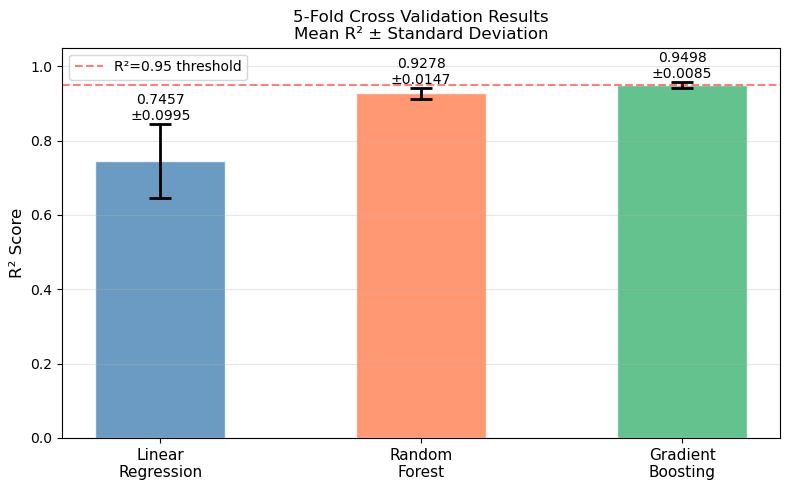

In [79]:
fig, ax = plt.subplots(figsize=(8, 5))

models_cv = {
    'Linear\nRegression': cv_lr,
    'Random\nForest': cv_rf,
    'Gradient\nBoosting': cv_gb
}

colors = ['steelblue', 'coral', 'mediumseagreen']
positions = range(len(models_cv))

for pos, (name, scores), color in zip(positions, models_cv.items(), colors):
    ax.bar(pos, scores.mean(), color=color, 
           alpha=0.8, edgecolor='white', width=0.5)
    ax.errorbar(pos, scores.mean(), yerr=scores.std(),
                fmt='none', color='black', capsize=8,
                linewidth=2, capthick=2)
    ax.text(pos, scores.mean() + scores.std() + 0.01,
            f'{scores.mean():.4f}\n±{scores.std():.4f}',
            ha='center', fontsize=10)

ax.set_xticks(list(positions))
ax.set_xticklabels(list(models_cv.keys()), fontsize=11)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title('5-Fold Cross Validation Results\n'
             'Mean R² ± Standard Deviation', fontsize=12)
ax.axhline(y=0.95, color='red', linestyle='--', 
           alpha=0.5, label='R²=0.95 threshold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('cross_validation_results.png', dpi=150)
plt.show()

In [81]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 3, 5]
}

print("Running grid search (this takes ~5 minutes)...")

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring='r2',
    verbose=1
)
grid_rf.fit(X_train_sc, y_train)

print(f"\nBest parameters: {grid_rf.best_params_}")
print(f"Best CV R²:      {grid_rf.best_score_:.4f}")

rf_tuned = grid_rf.best_estimator_
y_pred_tuned = rf_tuned.predict(X_val_sc)
r2_tuned = r2_score(y_val, y_pred_tuned)
print(f"Tuned RF R² on val: {r2_tuned:.4f}")
print(f"Original RF R²:     0.9620")
print(f"Improvement:        {(r2_tuned - 0.9620):.4f}")

Running grid search (this takes ~5 minutes)...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best parameters: {'max_depth': 10, 'min_samples_split': 3, 'n_estimators': 300}
Best CV R²:      0.8576
Tuned RF R² on val: 0.9629
Original RF R²:     0.9620
Improvement:        0.0009


In [90]:
!"{sys.executable}" -m pip install shap

In [89]:
!pip install numpy==1.26.4

In [91]:
!pip uninstall -y shap
!pip install shap==0.45.1 numpy==1.26.4 protobuf==5.29.3

Found existing installation: shap 0.45.1
Uninstalling shap-0.45.1:
  Successfully uninstalled shap-0.45.1
  Using cached shap-0.45.1-cp312-cp312-win_amd64.whl.metadata (25 kB)
Using cached shap-0.45.1-cp312-cp312-win_amd64.whl (455 kB)


In [92]:
import shap

# Use tuned RF for SHAP (best generalisation)
explainer = shap.TreeExplainer(rf_tuned)
shap_values = explainer.shap_values(X_test_sc)

print(f"SHAP values shape: {np.array(shap_values).shape}")
# Expected: (8, 30, 5) — 8 outputs, 30 test samples, 5 features

SHAP values shape: (30, 5, 8)


SHAP shape: (30, 5, 8)


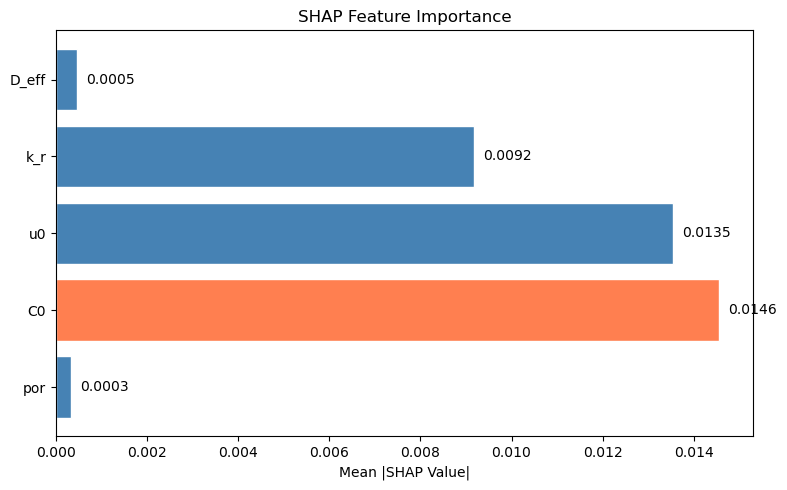

In [94]:
feature_names = ['por', 'C0', 'u0', 'k_r', 'D_eff']

shap_array = np.array(shap_values)
print("SHAP shape:", shap_array.shape)

if shap_array.shape[-1] == 5:
    mean_shap = np.mean(np.abs(shap_array), axis=tuple(range(shap_array.ndim - 1)))
elif shap_array.shape[1] == 5:
    mean_shap = np.mean(np.abs(shap_array), axis=(0, 2))
else:
    raise ValueError(f"Cannot find feature axis in shape {shap_array.shape}")

plt.figure(figsize=(8, 5))
colors = ['steelblue' if v < max(mean_shap) else 'coral' for v in mean_shap]

bars = plt.barh(feature_names, mean_shap, color=colors, edgecolor='white')
plt.xlabel('Mean |SHAP Value|')
plt.title('SHAP Feature Importance')

for bar, val in zip(bars, mean_shap):
    plt.text(val + 0.0002, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center')

plt.tight_layout()
plt.show()

SHAP shape: (30, 5, 8)
X_test_sc shape: (30, 5)


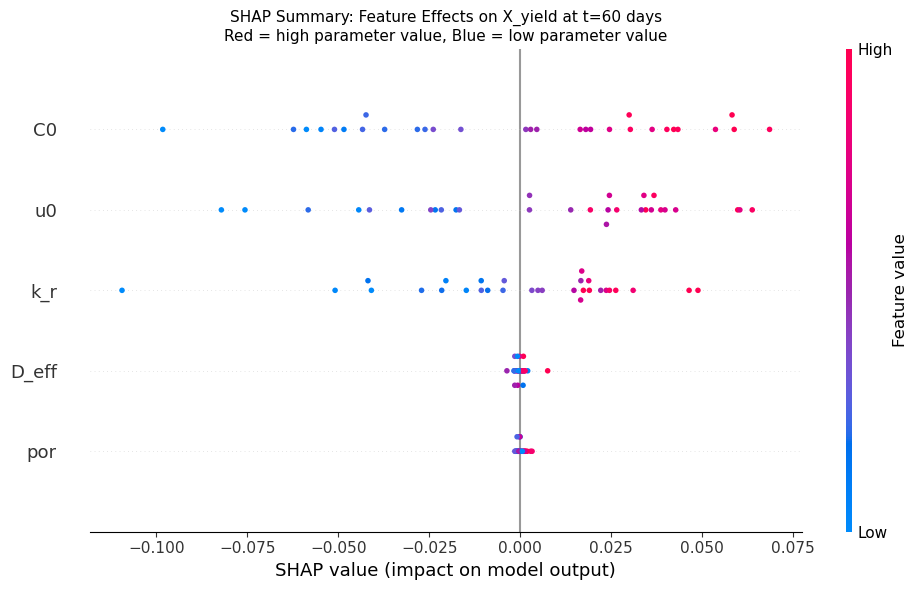

In [96]:
# SHAP for X_60d output only
feature_names = ['por', 'C0', 'u0', 'k_r', 'D_eff']

shap_array = np.array(shap_values)
print("SHAP shape:", shap_array.shape)
print("X_test_sc shape:", X_test_sc.shape)

# Pick the 60-day output safely
if shap_array.shape[0] == 8 and shap_array.shape[-1] == 5:
    # shape like (n_outputs, n_samples, n_features)
    shap_60d = shap_array[7]
elif shap_array.shape[-1] == 8 and shap_array.shape[1] == 5:
    # shape like (n_samples, n_features, n_outputs)
    shap_60d = shap_array[:, :, 7]
else:
    raise ValueError(f"Unexpected SHAP shape: {shap_array.shape}")

# Make sure SHAP and X have matching sample count
if X_test_sc.shape[0] != shap_60d.shape[0]:
    X_plot = X_test_sc[:shap_60d.shape[0], :]
else:
    X_plot = X_test_sc

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_60d,
    X_plot,
    feature_names=feature_names,
    show=False,
    plot_size=(10, 6)
)
plt.title(
    'SHAP Summary: Feature Effects on X_yield at t=60 days\n'
    'Red = high parameter value, Blue = low parameter value',
    fontsize=11
)
plt.tight_layout()
plt.savefig('shap_beeswarm_60d.png', dpi=150, bbox_inches='tight')
plt.show()

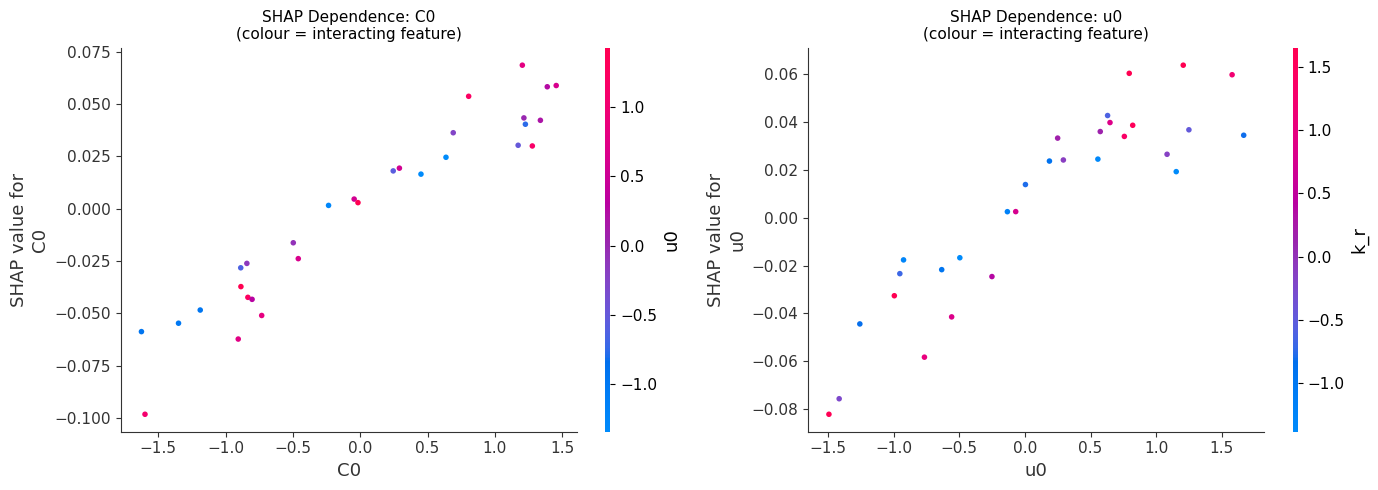

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# C0 dependence
shap.dependence_plot(
    1,  # index of C0
    shap_60d,
    X_test_sc,
    feature_names=feature_names,
    ax=axes[0],
    show=False
)
axes[0].set_title('SHAP Dependence: C0\n(colour = interacting feature)',
                  fontsize=11)

# u0 dependence  
shap.dependence_plot(
    2,  # index of u0
    shap_60d,
    X_test_sc,
    feature_names=feature_names,
    ax=axes[1],
    show=False
)
axes[1].set_title('SHAP Dependence: u0\n(colour = interacting feature)',
                  fontsize=11)

plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150)
plt.show()

In [107]:
app_code = '''
import streamlit as st
import numpy as np
import joblib
from tensorflow import keras
import matplotlib.pyplot as plt

# Load models
scaler = joblib.load("scaler_X.pkl")
scaler_y = joblib.load("scaler_y.pkl")
model = keras.models.load_model("ann_model.h5")

z
st.title("Heap Leach Extraction Yield Predictor")
st.markdown("ANN surrogate model — R² = 0.9902")

col1, col2 = st.columns([1, 2])

with col1:
    C0    = st.slider("C₀ (mol/m³)", 0.1, 1.0, 0.5, 0.01)
    u0    = st.slider("u₀ (×10⁻⁵ m/s)", 1.0, 10.0, 3.0, 0.1) * 1e-5
    kr    = st.slider("k_r (×10⁻⁸ m/s)", 1.0, 100.0, 50.0, 0.5) * 1e-8
    por   = st.slider("Porosity φ", 0.25, 0.50, 0.35, 0.01)
    deff  = st.slider("D_eff (×10⁻¹⁰ m²/s)", 1.0, 10.0, 4.0, 0.1) * 1e-10

X_in = np.array([[por, C0, u0, kr, deff]])
X_sc = scaler.transform(X_in)
y_sc = model.predict(X_sc)
y = scaler_y.inverse_transform(y_sc)[0]

time_days = [1, 3, 7, 14, 21, 30, 45, 60]

with col2:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(time_days, y, "bo-", linewidth=2, markersize=7)
    ax.fill_between(time_days, y*0.95, y*1.05, alpha=0.15)
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Extraction Yield")
    ax.set_title("Predicted Extraction Yield Curve")
    ax.grid(True, alpha=0.3)
    st.pyplot(fig)

    st.metric("Yield at 60 days", f"{y[-1]*100:.2f}%")
    st.metric("Yield at 21 days", f"{y[4]*100:.2f}%")
'''

with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

print("app.py saved!")
print("\nTo run: open terminal in project folder and type:")
print("  pip install streamlit")
print("  streamlit run app.py")

app.py saved!

To run: open terminal in project folder and type:
  pip install streamlit
  streamlit run app.py


In [102]:
from sklearn.preprocessing import StandardScaler
import joblib

# Example data (replace with your dataset)
X_train = [[1, 200], [2, 300], [3, 400]]

# Create scaler
scaler = StandardScaler()

# Fit scaler
scaler.fit(X_train)

# Save scaler
joblib.dump(scaler, "scaler_X.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


In [105]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler_y = StandardScaler()
scaler_y.fit(y_train.reshape(-1, 1))  # your target data

joblib.dump(scaler_y, "scaler_y.pkl")

['scaler_y.pkl']

In [109]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
print("Widgets version:", widgets.__version__)


Widgets version: 7.8.1


In [118]:
import joblib
import os

folder = r'C:\Users\DNYANESHWARI DEORE\Downloads\Course\2nd Year\MME\4TH SEM\PEM\ML PROJECT\HEAP LEACHING'

# Save scaler with correct column names
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(os.path.join(folder, 'comsol_results_fixed.csv'))
X = df[['por', 'C0', 'u0', 'k_r', 'D_eff']].values
scaler_X = StandardScaler().fit(X)
joblib.dump(scaler_X, os.path.join(folder, 'scaler_X.pkl'))
joblib.dump(scaler_y, os.path.join(folder, 'scaler_y.pkl'))
joblib.dump(rf, os.path.join(folder, 'random_forest_model.pkl'))
model_ann.save(os.path.join(folder, 'ann_model.keras'))

print("All files saved to HEAP LEACHING folder ✅")

All files saved to HEAP LEACHING folder ✅


In [119]:
import os

folder = r'C:\Users\DNYANESHWARI DEORE\Downloads\Course\2nd Year\MME\4TH SEM\PEM\ML PROJECT\HEAP LEACHING'

# Save ANN model
model_ann.save(os.path.join(folder, 'ann_model.keras'))

# Save all other files to same folder
import joblib
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(os.path.join(folder, 'comsol_results_fixed.csv'))
X = df[['por', 'C0', 'u0', 'k_r', 'D_eff']].values
y = df[['X_1d','X_3d','X_7d','X_14d','X_21d','X_30d','X_45d','X_60d']].values

scaler_X_new = StandardScaler().fit(X)
scaler_y_new = StandardScaler().fit(y)

joblib.dump(scaler_X_new, os.path.join(folder, 'scaler_X.pkl'))
joblib.dump(scaler_y_new, os.path.join(folder, 'scaler_y.pkl'))
joblib.dump(rf,           os.path.join(folder, 'random_forest_model.pkl'))

print("Files saved:")
for f in ['ann_model.keras','scaler_X.pkl','scaler_y.pkl','random_forest_model.pkl']:
    path = os.path.join(folder, f)
    exists = os.path.exists(path)
    print(f"  {f}: {'✅' if exists else '❌ MISSING'}")

Files saved:
  ann_model.keras: ✅
  scaler_X.pkl: ✅
  scaler_y.pkl: ✅
  random_forest_model.pkl: ✅


In [122]:
import os

folder = r'C:\Users\DNYANESHWARI DEORE\Downloads\Course\2nd Year\MME\4TH SEM\PEM\ML PROJECT\HEAP LEACHING'
app_path = os.path.join(folder, 'app.py')

with open(app_path, 'r', encoding='utf-8') as f:
    content = f.read()

old = 'scaler_X = joblib.load("scaler_X.pkl")'
new = f'scaler_X = joblib.load(r"{folder}' + r'\scaler_X.pkl")'
content = content.replace(old, new)

old = 'scaler_y = joblib.load("scaler_y.pkl")'
new = f'scaler_y = joblib.load(r"{folder}' + r'\scaler_y.pkl")'
content = content.replace(old, new)

old = 'if os.path.exists("ann_model.keras"):'
new = f'if os.path.exists(r"{folder}' + r'\ann_model.keras"):'
content = content.replace(old, new)

old = 'model = keras.models.load_model("ann_model.keras")'
new = f'model = keras.models.load_model(r"{folder}' + r'\ann_model.keras")'
content = content.replace(old, new)

old = 'elif os.path.exists("ann_model.h5"):'
new = 'elif False:  # skip h5'
content = content.replace(old, new)

old = 'elif os.path.exists("random_forest_model.pkl"):'
new = f'elif os.path.exists(r"{folder}' + r'\random_forest_model.pkl"):'
content = content.replace(old, new)

old = 'model = joblib.load("random_forest_model.pkl")'
new = f'model = joblib.load(r"{folder}' + r'\random_forest_model.pkl")'
content = content.replace(old, new)

with open(app_path, 'w', encoding='utf-8') as f:
    f.write(content)

print("app.py fixed ✅")
print("Now run in Command Prompt:")
print(f'streamlit run "{app_path}"')

app.py fixed ✅
Now run in Command Prompt:
streamlit run "C:\Users\DNYANESHWARI DEORE\Downloads\Course\2nd Year\MME\4TH SEM\PEM\ML PROJECT\HEAP LEACHING\app.py"


In [123]:
import os

folder = r'C:\Users\DNYANESHWARI DEORE\Downloads\Course\2nd Year\MME\4TH SEM\PEM\ML PROJECT\HEAP LEACHING'
app_path = os.path.join(folder, 'app.py')

app_code = r'''import streamlit as st
import numpy as np
import joblib
import matplotlib.pyplot as plt
import os
from tensorflow import keras

# ── Page config ──────────────────────────────────────────────────────────────
st.set_page_config(page_title="Heap Leach Yield Predictor", page_icon="⛏️", layout="wide")

FOLDER = r"C:\Users\DNYANESHWARI DEORE\Downloads\Course\2nd Year\MME\4TH SEM\PEM\ML PROJECT\HEAP LEACHING"

@st.cache_resource
def load_models():
    scaler_X = joblib.load(os.path.join(FOLDER, "scaler_X.pkl"))
    scaler_y = joblib.load(os.path.join(FOLDER, "scaler_y.pkl"))
    model = keras.models.load_model(
        os.path.join(FOLDER, "ann_model.keras"),
        compile=False
    )
    return scaler_X, scaler_y, model

scaler_X, scaler_y, model = load_models()

TIME_DAYS   = [1, 3, 7, 14, 21, 30, 45, 60]
TIME_LABELS = ["1d","3d","7d","14d","21d","30d","45d","60d"]

st.title("⛏️ Heap Leach Extraction Yield Predictor")
st.markdown("**ANN surrogate model** trained on 200 COMSOL simulations")
st.divider()

st.sidebar.header("🔧 Input Parameters")
por   = st.sidebar.slider("Porosity (por)",                   0.25, 0.50, 0.35, 0.01)
C0    = st.sidebar.slider("Inlet acid C₀ (mol/m³)",          0.10, 1.00, 0.50, 0.01)
u0    = st.sidebar.slider("Darcy velocity u₀ (×10⁻⁵ m/s)",  1.0,  10.0, 3.0,  0.1)
k_r   = st.sidebar.slider("Reaction rate k_r (×10⁻⁷ m/s)",  0.1,  10.0, 5.0,  0.1)
D_eff = st.sidebar.slider("Diffusivity D_eff (×10⁻¹⁰ m²/s)",1.0,  10.0, 4.0,  0.1)

input_vec = np.array([[por, C0, u0*1e-5, k_r*1e-7, D_eff*1e-10]])
input_sc  = scaler_X.transform(input_vec)
pred_sc   = model.predict(input_sc, verbose=0)
pred      = np.clip(scaler_y.inverse_transform(pred_sc)[0], 0, 1)

col1, col2, col3, col4 = st.columns(4)
col1.metric("X at  7 days", f"{pred[2]*100:.2f}%")
col2.metric("X at 14 days", f"{pred[3]*100:.2f}%")
col3.metric("X at 30 days", f"{pred[5]*100:.2f}%")
col4.metric("X at 60 days", f"{pred[7]*100:.2f}%")

st.divider()

col_plot, col_table = st.columns([2, 1])
with col_plot:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(TIME_DAYS, pred*100, "o-", color="steelblue", linewidth=2.5, markersize=8)
    ax.fill_between(TIME_DAYS, pred*100*0.92, pred*100*1.08, alpha=0.15, color="steelblue")
    ax.set_xlabel("Time (days)"); ax.set_ylabel("Extraction Yield X (%)")
    ax.set_title("Predicted Copper Extraction Yield Over Time")
    ax.grid(True, alpha=0.3); plt.tight_layout()
    st.pyplot(fig); plt.close()

with col_table:
    import pandas as pd
    st.dataframe(pd.DataFrame({"Time": TIME_LABELS, "X yield": [f"{v*100:.3f}%" for v in pred]}),
                 hide_index=True, use_container_width=True)

st.divider()
st.caption("2nd Year MME Project · COMSOL + Python ML Pipeline")
'''

with open(app_path, 'w', encoding='utf-8') as f:
    f.write(app_code)

print("app.py rewritten ✅")
print(f'\nNow run in Command Prompt:')
print(f'streamlit run "{app_path}"')

app.py rewritten ✅

Now run in Command Prompt:
streamlit run "C:\Users\DNYANESHWARI DEORE\Downloads\Course\2nd Year\MME\4TH SEM\PEM\ML PROJECT\HEAP LEACHING\app.py"
